# Calibration Results Comparison Across 5 TF Perturb-seq Benchmark Datasets

Loads the `calibrate.py --from-uns` outputs (see `run_inference_calibration_benchmarks.sh`) for each of the 5 benchmark datasets and produces comparison figures.

**Per-dataset inputs** (from `<dataset_dir>/Calibration/`):
- `{prefix}_trans_calibrated_results.tsv` — all element→gene tests, NTC empirical-null calibrated (`empirical_pval_adj`). Split here into **direct** (`is_direct_target == True`, element's own target gene) and **trans** (`is_direct_target == False`, genuinely trans-acting) subsets.
- `{prefix}_trans_calibrated_direct_target_results.tsv` — same as the direct-target subset above, provided as its own file by `calibrate.py`.
- `{prefix}_cis_bh_results.tsv` — cis-window tests, plain BH-FDR corrected (no NTC empirical null — see `calibrate_cis_bh()` in `calibrate.py`). Has **two** independent significance columns, `sceptre_p_value_adj` and `perturbo_p_value_adj`, since cis was tested by both methods. **This notebook defaults to `perturbo_p_value_adj`** (set `CIS_SIG_COL` below to switch) — cis significance is therefore not directly comparable in magnitude to the direct/trans empirical-null p-values, since it's a different statistical procedure entirely.

**Significance threshold:** FDR < 0.1 throughout (`SIG_THRESHOLD` below), matching the threshold requested for the UpSet plots — applied consistently to the barplots too for consistency.

**Dependency:** the UpSet plots need the `upsetplot` package (`pip install upsetplot`), which isn't used anywhere else in this project — install it in whichever conda env runs this notebook's kernel before running the UpSet cells.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from upsetplot import UpSet, from_contents
    HAVE_UPSETPLOT = True
except ImportError:
    HAVE_UPSETPLOT = False
    print("WARNING: 'upsetplot' not installed (pip install upsetplot). "
          "The UpSet plot cells near the end of this notebook will not run until it is.")

%matplotlib inline

In [2]:
BASE_DIR = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets"
OUT_DIR  = "/hpc/group/gersbachlab/seg95/tf_perturb_seq/src/tf_perturb_seq/gene_program_discovery/benchmark_figures_calibration"
os.makedirs(OUT_DIR, exist_ok=True)

SIG_THRESHOLD = 0.1        # FDR threshold applied everywhere in this notebook
CIS_SIG_COL   = "perturbo_p_value_adj"   # or "sceptre_p_value_adj" -- see markdown above

#POSITIVE_CONTROL_TFS = ["TFEC", "CD81"]
# TRY TF GENES WITH EXPECTED TRANS EFFECTS, LIKE OCT4
POSITIVE_CONTROL_TFS = ["OCT4", "EZH2"]

# Same palette as benchmark_cnmf_comparison.py / qc_comparison_5_datasets.ipynb
PALETTE = {
    "CC-Perturb":        "#7030a0",
    "GEM-x v3 10xv3 5'": "#00b050",
    "HTv2 10xv3 5'":     "#ff4b3d",
    "HTO 10xv3 5'":      "#00b0f0",
    "10xv3 3'":          "#ebce9a",
}

# One entry per dataset. "prefix" matches the PREFIX values in
# run_inference_calibration_benchmarks.sh (also the filename prefix calibrate.py wrote).
DATASETS = [
    {
        "display_name": "CC-Perturb (Engreitz)",
        "dir":          "Engreitz_WTC11-benchmark_TF-Perturb-seq",
        "prefix":       "engreitz",
        "palette_key":  "CC-Perturb",
    },
    {
        "display_name": "GEM-X v3 10xv3 5' (Gersbach)",
        "dir":          "Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3",
        "prefix":       "gersbach_gemx",
        "palette_key":  "GEM-x v3 10xv3 5'",
    },
    {
        "display_name": "HTv2 10xv3 5' (Gersbach)",
        "dir":          "Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2",
        "prefix":       "gersbach_htv2",
        "palette_key":  "HTv2 10xv3 5'",
    },
    {
        "display_name": "HTO 10xv3 5' (Hon)",
        "dir":          "Hon_WTC11-benchmark_TF-Perturb-seq",
        "prefix":       "hon",
        "palette_key":  "HTO 10xv3 5'",
    },
    {
        "display_name": "10xv3 3' (Huangfu)",
        "dir":          "Huangfu_WTC11-benchmark_TF-Perturb-seq",
        "prefix":       "huangfu",
        "palette_key":  "10xv3 3'",
    },
]

for ds in DATASETS:
    ds["color"] = PALETTE[ds["palette_key"]]

DATASET_NAMES = [ds["display_name"] for ds in DATASETS]
COLOR_MAP     = {ds["display_name"]: ds["color"] for ds in DATASETS}

In [3]:
def calibration_path(ds, suffix):
    return os.path.join(BASE_DIR, ds["dir"], "Calibration", f"{ds['prefix']}_{suffix}")


def safe_read_tsv(path, label):
    if not os.path.exists(path):
        print(f"  WARNING: missing {label}: {path}")
        return None
    df = pd.read_csv(path, sep="\t")
    print(f"  [{label}] {df.shape[0]:,} rows: {path}")
    return df


def grouped_bar_row(df, metrics, titles, fname, ylabels=None, figsize_per_panel=(3.5, 4.5)):
    """One subplot per metric, one bar per dataset within each subplot."""
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_panel[0] * n, figsize_per_panel[1]))
    if n == 1:
        axes = [axes]
    for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
        vals   = df[metric].values
        colors = [COLOR_MAP[d] for d in df.index]
        ax.bar(range(len(df)), vals, color=colors, edgecolor="black", linewidth=0.5)
        ax.set_xticks(range(len(df)))
        ax.set_xticklabels(df.index, rotation=45, ha="right", fontsize=8)
        ax.set_title(title, fontsize=11, fontweight="bold")
        if ylabels is not None:
            ax.set_ylabel(ylabels[i], fontsize=9)
        for x, v in enumerate(vals):
            ax.text(x, v, f"{int(v)}", ha="center", va="bottom", fontsize=8)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, fname), dpi=300, bbox_inches="tight")
    return fig

## Load calibration outputs

In [4]:
trans_all_by_ds   = {}   # display_name -> full trans_calibrated_results.tsv
trans_direct_by_ds = {}  # display_name -> trans_calibrated_direct_target_results.tsv
cis_by_ds          = {}  # display_name -> cis_bh_results.tsv

sig_records = []

for ds in DATASETS:
    name = ds["display_name"]
    print(f"\n=== {name} ({ds['prefix']}) ===")

    trans_all    = safe_read_tsv(calibration_path(ds, "trans_calibrated_results.tsv"), "trans (all)")
    trans_direct = safe_read_tsv(calibration_path(ds, "trans_calibrated_direct_target_results.tsv"), "trans (direct target)")
    cis_df       = safe_read_tsv(calibration_path(ds, "cis_bh_results.tsv"), "cis (BH)")

    trans_all_by_ds[name]    = trans_all
    trans_direct_by_ds[name] = trans_direct
    cis_by_ds[name]          = cis_df

    n_direct_sig = int((trans_direct["empirical_pval_adj"] < SIG_THRESHOLD).sum()) if trans_direct is not None else np.nan

    n_cis_sig = np.nan
    if cis_df is not None:
        if CIS_SIG_COL in cis_df.columns:
            n_cis_sig = int((cis_df[CIS_SIG_COL] < SIG_THRESHOLD).sum())
        else:
            print(f"  WARNING: '{CIS_SIG_COL}' not in cis results columns {list(cis_df.columns)}")

    n_trans_sig = np.nan
    if trans_all is not None:
        trans_only = trans_all[~trans_all["is_direct_target"]]
        n_trans_sig = int((trans_only["empirical_pval_adj"] < SIG_THRESHOLD).sum())

    sig_records.append({
        "dataset":            name,
        "n_sig_direct":       n_direct_sig,
        "n_sig_cis":          n_cis_sig,
        "n_sig_trans":        n_trans_sig,
    })

sig_df = pd.DataFrame(sig_records).set_index("dataset").loc[DATASET_NAMES]
print("\nDone loading all datasets.")


=== CC-Perturb (Engreitz) (engreitz) ===
  [trans (all)] 800,088 rows: /hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Engreitz_WTC11-benchmark_TF-Perturb-seq/Calibration/engreitz_trans_calibrated_results.tsv
  [trans (direct target)] 49 rows: /hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Engreitz_WTC11-benchmark_TF-Perturb-seq/Calibration/engreitz_trans_calibrated_direct_target_results.tsv
  [cis (BH)] 46 rows: /hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Engreitz_WTC11-benchmark_TF-Perturb-seq/Calibration/engreitz_cis_bh_results.tsv

=== GEM-X v3 10xv3 5' (Gersbach) (gersbach_gemx) ===
  [trans (all)] 1,018,314 rows: /hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3/Calibration/gersbach_gemx_trans_calibrated_results.tsv
  [trans (direct target)] 55 rows: /hpc/group/gersbachlab/seg95/tf_perturb_seq/datasets/Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3/Calibration/gersbach_gemx_trans_calibrated_direct_target_res

In [5]:
sig_df

,n_sig_direct,n_sig_cis,n_sig_trans
dataset,,,
CC-Perturb (Engreitz),25,29,1123
GEM-X v3 10xv3 5' (Gersbach),43,42,6605
HTv2 10xv3 5' (Gersbach),28,35,5879
HTO 10xv3 5' (Hon),34,33,3103
10xv3 3' (Huangfu),38,32,8716


## Figure 1: Significant hits per dataset (direct / cis / trans)
Number of element→gene tests passing FDR < 0.1, split into direct-target, cis-window, and genuinely-trans categories.

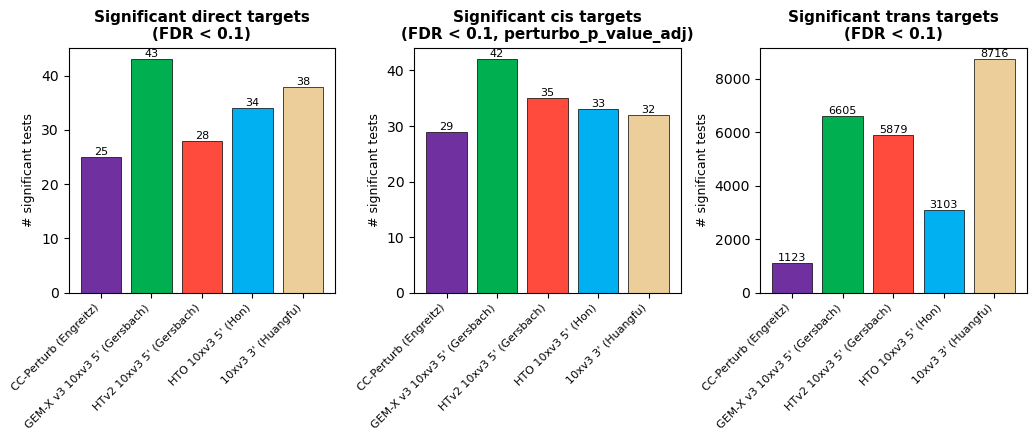

In [6]:
fig1 = grouped_bar_row(
    sig_df,
    metrics=["n_sig_direct", "n_sig_cis", "n_sig_trans"],
    titles=[
        f"Significant direct targets\n(FDR < {SIG_THRESHOLD})",
        f"Significant cis targets\n(FDR < {SIG_THRESHOLD}, {CIS_SIG_COL})",
        f"Significant trans targets\n(FDR < {SIG_THRESHOLD})",
    ],
    ylabels=["# significant tests"] * 3,
    fname="CAL1_significant_hits_barplots.png",
)
plt.show()

## Figure 2: UpSet plots of FDR < 0.1 DEG overlap for positive control TFs

For each TF, pulls every row in `trans_calibrated_results.tsv` where `element_symbol == TF` (i.e. that TF was the perturbed element), takes the set of `tested_gene_symbol`s with `empirical_pval_adj < SIG_THRESHOLD` in each dataset, and plots how those significant-gene sets overlap across the 5 datasets. Includes both direct and trans effects of perturbing the TF (not restricted to the trans-only subset), since "DEGs" here means all genes significantly affected by the perturbation.

In [7]:
def get_deg_set(trans_df, tf_symbol, threshold=SIG_THRESHOLD):
    if trans_df is None:
        return set()
    sub = trans_df[trans_df["element_symbol"] == tf_symbol]
    if len(sub) == 0:
        return set()
    sig = sub[sub["empirical_pval_adj"] < threshold]
    return set(sig["tested_gene_symbol"].dropna().unique())


deg_sets_by_tf = {}
for tf in POSITIVE_CONTROL_TFS:
    print(f"\n=== {tf} ===")
    contents = {}
    for ds in DATASETS:
        name = ds["display_name"]
        deg_set = get_deg_set(trans_all_by_ds.get(name), tf)
        contents[name] = deg_set
        if len(deg_set) == 0:
            print(f"  WARNING: 0 significant DEGs for {tf} in {name} "
                  f"(TF may not be a screened perturbation in this dataset, or symbol mismatch)")
        else:
            print(f"  {name}: {len(deg_set)} DEGs")
    deg_sets_by_tf[tf] = contents


=== OCT4 ===

=== EZH2 ===
  CC-Perturb (Engreitz): 84 DEGs
  GEM-X v3 10xv3 5' (Gersbach): 739 DEGs
  HTv2 10xv3 5' (Gersbach): 161 DEGs
  HTO 10xv3 5' (Hon): 251 DEGs
  10xv3 3' (Huangfu): 389 DEGs


Skipping OCT4: no significant DEGs found in any dataset.


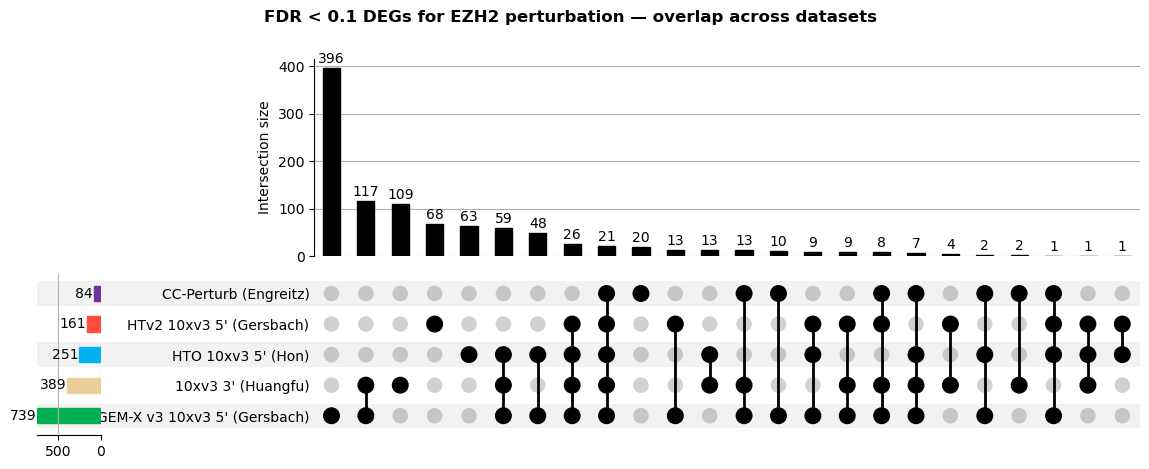

In [8]:
if not HAVE_UPSETPLOT:
    print("Skipping UpSet plots -- install upsetplot first (pip install upsetplot).")
else:
    for tf in POSITIVE_CONTROL_TFS:
        contents = deg_sets_by_tf[tf]
        if all(len(s) == 0 for s in contents.values()):
            print(f"Skipping {tf}: no significant DEGs found in any dataset.")
            continue

        upset_data = from_contents(contents)
        upset = UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality")

        # Best-effort per-dataset coloring to match PALETTE; not all upsetplot
        # versions support style_categories, so this degrades gracefully.
        try:
            for ds in DATASETS:
                upset.style_categories(ds["display_name"], bar_facecolor=ds["color"])
        except AttributeError:
            pass

        fig = plt.figure(figsize=(10, 6))
        upset.plot(fig=fig)
        fig.suptitle(
            f"FDR < {SIG_THRESHOLD} DEGs for {tf} perturbation \u2014 overlap across datasets",
            fontweight="bold",
        )
        fig.savefig(os.path.join(OUT_DIR, f"CAL2_upset_{tf}.png"), dpi=300, bbox_inches="tight")
        plt.show()

## Figure 3: Pairwise log2FC scatterplots for positive control TFs

For each TF, every gene tested against it (`element_symbol == TF`) in `trans_calibrated_results.tsv`, **regardless of significance** -- i.e. the raw `log2fc` column, not filtered by `empirical_pval_adj`. For every pair of datasets, scatters that TF's log2FC across all genes common to both datasets' gene panels, with a y=x reference line and Pearson r as a rough reproducibility check. If a TF has duplicate rows for the same gene within a dataset (e.g. multiple coordinate-distinct elements mapping to the same TF symbol), their log2FC values are averaged.

Skipping OCT4: log2FC available for fewer than 2 datasets.


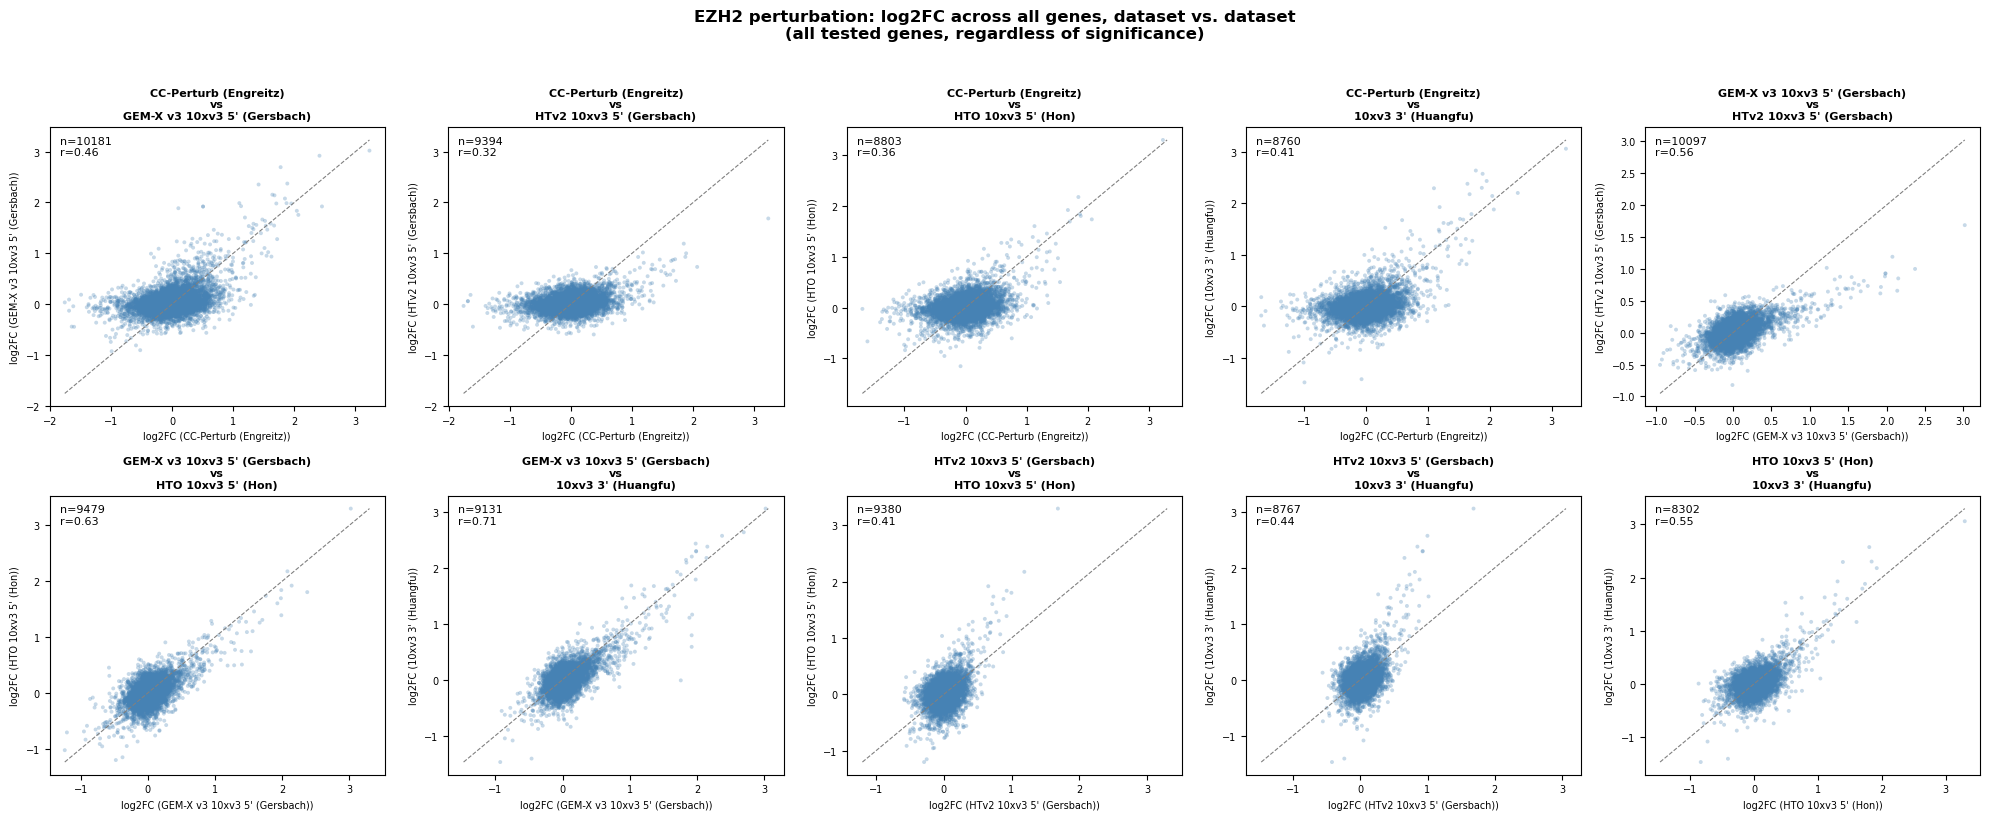

In [9]:
def get_gene_log2fc(trans_df, tf_symbol):
    """All genes tested against tf_symbol -> log2fc, regardless of significance."""
    if trans_df is None:
        return pd.Series(dtype=float)
    sub = trans_df[trans_df["element_symbol"] == tf_symbol]
    sub = sub.dropna(subset=["tested_gene_symbol", "log2fc"])
    if len(sub) == 0:
        return pd.Series(dtype=float)
    return sub.groupby("tested_gene_symbol")["log2fc"].mean()


def pairwise_log2fc_scatter_grid(tf_symbol, fname):
    log2fc_by_ds = {
        name: get_gene_log2fc(trans_all_by_ds.get(name), tf_symbol)
        for name in DATASET_NAMES
    }

    available = [name for name in DATASET_NAMES if len(log2fc_by_ds[name]) > 0]
    if len(available) < 2:
        print(f"Skipping {tf_symbol}: log2FC available for fewer than 2 datasets.")
        return None

    pairs   = [(a, b) for i, a in enumerate(available) for b in available[i + 1:]]
    n_pairs = len(pairs)
    n_cols  = min(5, n_pairs)
    n_rows  = int(np.ceil(n_pairs / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)

    for idx, (a, b) in enumerate(pairs):
        ax = axes[idx // n_cols, idx % n_cols]
        sa, sb = log2fc_by_ds[a], log2fc_by_ds[b]
        common = sa.index.intersection(sb.index)
        x, y   = sa.loc[common].values, sb.loc[common].values

        ax.scatter(x, y, s=8, alpha=0.3, color="steelblue", edgecolor="none")
        if len(x) > 0:
            lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
            ax.plot([lo, hi], [lo, hi], color="grey", linestyle="--", linewidth=0.8)
        if len(common) >= 2:
            r = np.corrcoef(x, y)[0, 1]
            ax.text(0.03, 0.97, f"n={len(common)}\nr={r:.2f}", transform=ax.transAxes,
                    ha="left", va="top", fontsize=8)

        ax.set_title(f"{a}\nvs\n{b}", fontsize=8, fontweight="bold")
        ax.set_xlabel(f"log2FC ({a})", fontsize=7)
        ax.set_ylabel(f"log2FC ({b})", fontsize=7)
        ax.tick_params(labelsize=7)

    for empty_idx in range(n_pairs, n_rows * n_cols):
        axes[empty_idx // n_cols, empty_idx % n_cols].axis("off")

    fig.suptitle(
        f"{tf_symbol} perturbation: log2FC across all genes, dataset vs. dataset\n"
        f"(all tested genes, regardless of significance)",
        fontsize=12, fontweight="bold", y=1.02,
    )
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, fname), dpi=300, bbox_inches="tight")
    return fig


for tf in POSITIVE_CONTROL_TFS:
    fig = pairwise_log2fc_scatter_grid(tf, fname=f"CAL3_log2fc_scatter_{tf}.png")
    if fig is not None:
        plt.show()

All figures are also saved as PNGs to `OUT_DIR`:
```
/hpc/group/gersbachlab/seg95/tf_perturb_seq/src/tf_perturb_seq/gene_program_discovery/benchmark_figures_calibration
```